# Data Characteristics and Preprocessing Techniques

**Author:** Phabel Antonio Lopez-Delgado, BSc.

This notebook provides a comprehensive exploration of essential data preprocessing and characterization techniques for tabular data. It covers categorical variable encoding (ordinal, binary, one‑hot), time‑based feature engineering (cyclic encoding), descriptive statistics and visualisation (histograms, KDE, boxplots, scatterplots), missing value imputation (mean, median, mode, KNN), outlier detection (IQR, Isolation Forest), data anonymization (pseudonymization, masking, generalisation), and feature scaling (Min‑Max normalisation). All techniques are demonstrated on synthetic datasets, ensuring reproducibility.

**Key techniques & libraries:**
- Pandas & NumPy – data manipulation and generation
- Scikit‑learn – encoders (`OrdinalEncoder`, `LabelBinarizer`, `OneHotEncoder`), imputers (`SimpleImputer`, `KNNImputer`), outlier detection (`IsolationForest`), scalers (`MinMaxScaler`, `StandardScaler`, `RobustScaler`)
- Matplotlib & Seaborn – publication‑quality visualisations with consistent styling

**Data source:**  
Synthetic datasets generated within the notebook – no external files required.

In [28]:
# Imports and configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    OrdinalEncoder,
    LabelBinarizer,
    OneHotEncoder,
    MinMaxScaler,
    StandardScaler,
    RobustScaler
)
from sklearn.ensemble import IsolationForest

# Reproducibility seeds
np.random.seed(42)

# High-resolution plot settings
%config InlineBackend.figure_format = 'retina'

# Matplotlib style for publication-quality figures
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.titlesize'] = 14
sns.set_style("whitegrid")

In [37]:
def validate_dataframe(df, name="DataFrame"):
    """
    Print basic validation info for a DataFrame.
    
    Args:
        df (pd.DataFrame): Input DataFrame.
        name (str): Descriptive name for logging.
    """
    print(f"--- {name} Validation ---")
    print(f"Shape: {df.shape}")
    print(f"Column names: {df.columns.tolist()}")
    print(f"Data types:\n{df.dtypes}")
    print(f"Missing values per column:\n{df.isnull().sum()}")
    print(f"First 5 rows:\n{df.head()}")
    print("\n")

def plot_histogram_kde(data, column, bins=20, title=None, xlabel=None, figsize=(8, 6)):
    """
    Plot histogram with KDE overlay for a numeric column.
    
    Args:
        data (pd.Series): Numeric data.
        column (str): Column name for labeling.
        bins (int): Number of bins.
        title (str): Plot title.
        xlabel (str): X-axis label.
        figsize (tuple): Figure size.
    """
    plt.figure(figsize=figsize)
    sns.histplot(data, bins=bins, kde=True, color='blue', alpha=0.6)
    plt.title(title or f"Distribution of {column}")
    plt.xlabel(xlabel or column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

def plot_boxplot(data, y=None, x=None, title=None, xlabel=None, ylabel=None, figsize=(8, 6)):
    """
    Plot boxplot for a numeric column, optionally grouped by a categorical column.
    
    Args:
        data (pd.DataFrame): DataFrame containing the data.
        y (str): Numeric column name.
        x (str, optional): Categorical column for grouping.
        title (str): Plot title.
        xlabel (str): X-axis label.
        ylabel (str): Y-axis label.
        figsize (tuple): Figure size.
    """
    plt.figure(figsize=figsize)
    if x:
        sns.boxplot(x=x, y=y, data=data, palette="Set2")
    else:
        sns.boxplot(y=y, data=data, palette="Set2")
    plt.title(title or f"Boxplot of {y}")
    plt.xlabel(xlabel or (x if x else ""))
    plt.ylabel(ylabel or y)
    plt.tight_layout()
    plt.show()

def plot_scatter(data, x, y, title=None, xlabel=None, ylabel=None, figsize=(8, 6)):
    """
    Plot scatter plot between two numeric columns.
    
    Args:
        data (pd.DataFrame): DataFrame.
        x (str): Column for x-axis.
        y (str): Column for y-axis.
        title (str): Plot title.
        xlabel (str): X-axis label.
        ylabel (str): Y-axis label.
        figsize (tuple): Figure size.
    """
    plt.figure(figsize=figsize)
    sns.scatterplot(x=x, y=y, data=data, color='blue', alpha=0.7)
    plt.title(title or f"Relationship between {x} and {y}")
    plt.xlabel(xlabel or x)
    plt.ylabel(ylabel or y)
    plt.tight_layout()
    plt.show()

In [30]:
# Create sample dataset
data_cat = {
    "Nivel_educativo": [
        "Primaria", "Secundaria", "Preparatoria", "Universidad", "Preparatoria",
        "Secundaria", "Primaria", "Universidad", "Preparatoria", "Secundaria"
    ],
    "Ciudad": [
        "CDMX", "Guadalajara", "Monterrey", "CDMX", "Guadalajara",
        "Monterrey", "CDMX", "Guadalajara", "Monterrey", "CDMX"
    ],
    "Tiene_coche": [
        "Sí", "No", "Sí", "Sí", "No",
        "Sí", "No", "Sí", "No", "Sí"
    ],
    "Edad": [25, 30, 22, 35, 28, 40, 23, 32, 27, 29]
}

df_cat = pd.DataFrame(data_cat)
validate_dataframe(df_cat, "Original Categorical Data")

# Ordinal Encoding for education levels (ordered)
edu_order = ["Primaria", "Secundaria", "Preparatoria", "Universidad"]
ord_enc = OrdinalEncoder(categories=[edu_order])
df_cat["Nivel_educativo_encoded"] = ord_enc.fit_transform(df_cat[["Nivel_educativo"]])

# Binary Encoding for car ownership
lb = LabelBinarizer()
df_cat["Tiene_coche_encoded"] = lb.fit_transform(df_cat["Tiene_coche"])

# One-Hot Encoding for city (drop first to avoid multicollinearity)
ohe = OneHotEncoder(sparse_output=False, drop="first")
city_encoded = ohe.fit_transform(df_cat[["Ciudad"]])
city_cols = ohe.get_feature_names_out(["Ciudad"])
df_cat[city_cols] = city_encoded

# Drop original categorical columns
df_cat_encoded = df_cat.drop(columns=["Nivel_educativo", "Ciudad", "Tiene_coche"])
validate_dataframe(df_cat_encoded, "Encoded Data")

# Show result
print("Encoded DataFrame:")
display(df_cat_encoded.head(10))

--- Original Categorical Data Validation ---
Shape: (10, 4)
Column names: ['Nivel_educativo', 'Ciudad', 'Tiene_coche', 'Edad']
Data types:
Nivel_educativo    object
Ciudad             object
Tiene_coche        object
Edad                int64
dtype: object
Missing values per column:
Nivel_educativo    0
Ciudad             0
Tiene_coche        0
Edad               0
dtype: int64
First 5 rows:
  Nivel_educativo       Ciudad Tiene_coche  Edad
0        Primaria         CDMX          Sí    25
1      Secundaria  Guadalajara          No    30
2    Preparatoria    Monterrey          Sí    22
3     Universidad         CDMX          Sí    35
4    Preparatoria  Guadalajara          No    28


--- Encoded Data Validation ---
Shape: (10, 5)
Column names: ['Edad', 'Nivel_educativo_encoded', 'Tiene_coche_encoded', 'Ciudad_Guadalajara', 'Ciudad_Monterrey']
Data types:
Edad                         int64
Nivel_educativo_encoded    float64
Tiene_coche_encoded          int32
Ciudad_Guadalajara         flo

,Edad,Nivel_educativo_encoded,Tiene_coche_encoded,Ciudad_Guadalajara,Ciudad_Monterrey
0,25,0.0,1,0.0,0.0
1,30,1.0,0,1.0,0.0
2,22,2.0,1,0.0,1.0
3,35,3.0,1,0.0,0.0
4,28,2.0,0,1.0,0.0
5,40,1.0,1,0.0,1.0
6,23,0.0,0,0.0,0.0
7,32,3.0,1,1.0,0.0
8,27,2.0,0,0.0,1.0
9,29,1.0,1,0.0,0.0


## 2. Time‑Based Feature Engineering

For time series data, we extract cyclic features (sin/cos transformations) to preserve the cyclical nature of temporal variables (e.g., month, day). This is essential for models that cannot natively handle periodicity.

--- Time Series Data Validation ---
Shape: (10, 2)
Column names: ['Fecha', 'Ventas']
Data types:
Fecha     datetime64[ns]
Ventas             int64
dtype: object
Missing values per column:
Fecha     0
Ventas    0
dtype: int64
First 5 rows:
       Fecha  Ventas
0 2025-01-15     100
1 2025-02-20     150
2 2025-03-10     200
3 2025-04-05     180
4 2025-05-25     220




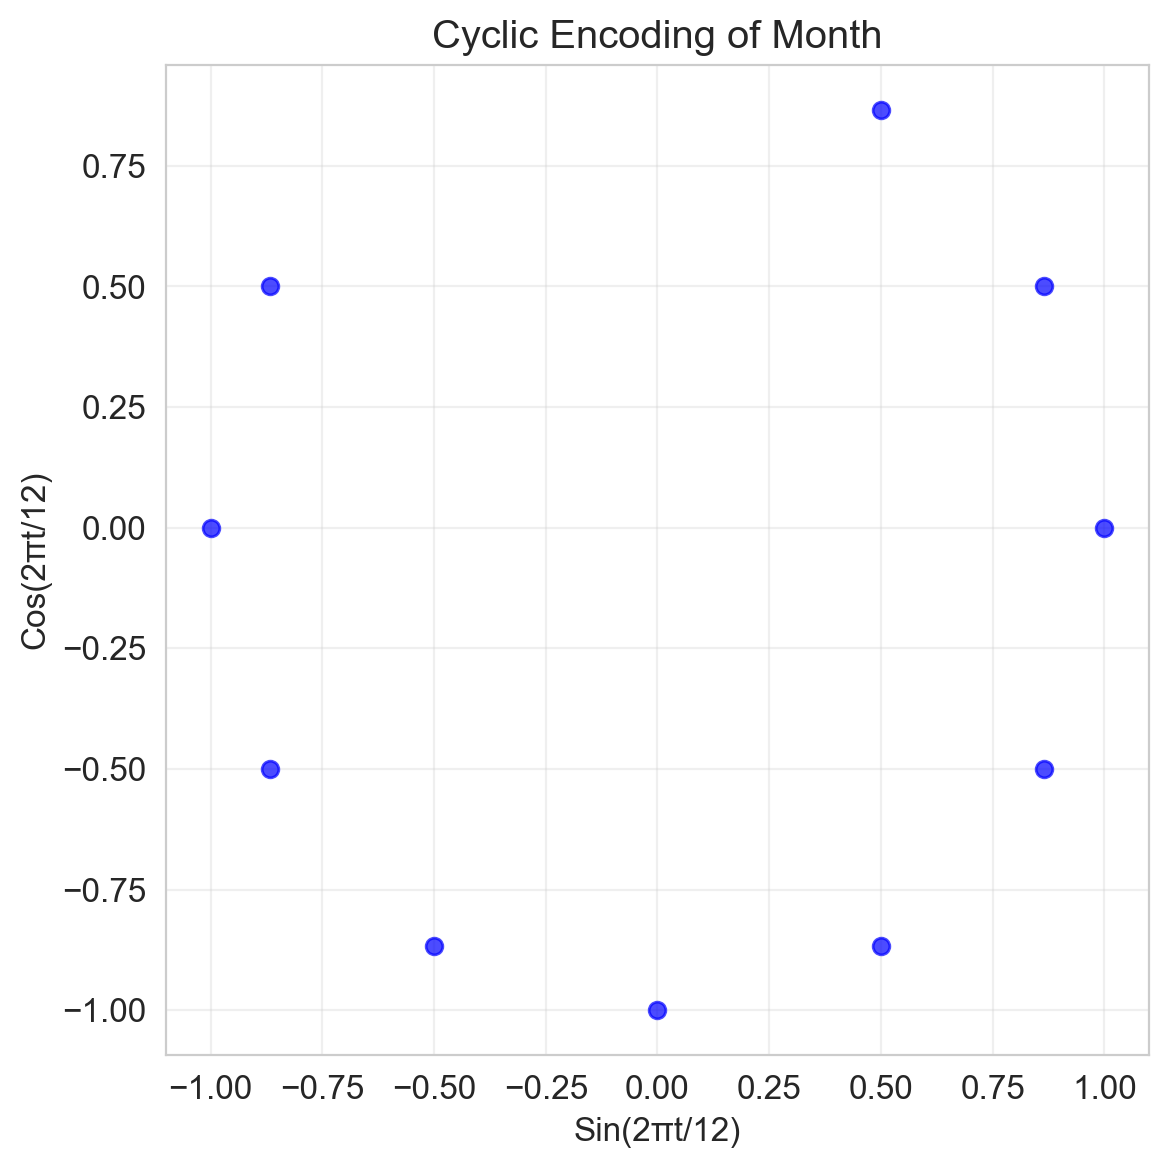

,Fecha,Ventas,Mes,Año,Dia,Mes_sin,Mes_cos,Dia_sin,Dia_cos
0,2025-01-15,100,1,2025,15,5.000000e-01,8.660254e-01,0.255353,0.966848
1,2025-02-20,150,2,2025,20,8.660254e-01,5.000000e-01,0.337523,0.941317
2,2025-03-10,200,3,2025,10,1.000000e+00,6.123234e-17,0.171293,0.985220
3,2025-04-05,180,4,2025,5,8.660254e-01,-5.000000e-01,0.085965,0.996298
4,2025-05-25,220,5,2025,25,5.000000e-01,-8.660254e-01,0.417194,0.908818
5,2025-06-30,250,6,2025,30,1.224647e-16,-1.000000e+00,0.493776,0.869589
6,2025-07-15,270,7,2025,15,-5.000000e-01,-8.660254e-01,0.255353,0.966848
7,2025-08-20,300,8,2025,20,-8.660254e-01,-5.000000e-01,0.337523,0.941317
8,2025-09-10,230,9,2025,10,-1.000000e+00,-1.836970e-16,0.171293,0.985220
9,2025-10-31,190,10,2025,31,-8.660254e-01,5.000000e-01,0.508671,0.860961


In [31]:
# Create time series data
data_time = {
    "Fecha": [
        "2025-01-15", "2025-02-20", "2025-03-10", "2025-04-05", "2025-05-25",
        "2025-06-30", "2025-07-15", "2025-08-20", "2025-09-10", "2025-10-31"
    ],
    "Ventas": [100, 150, 200, 180, 220, 250, 270, 300, 230, 190]
}

df_time = pd.DataFrame(data_time)
df_time["Fecha"] = pd.to_datetime(df_time["Fecha"])
validate_dataframe(df_time, "Time Series Data")

# Extract date components
df_time["Mes"] = df_time["Fecha"].dt.month
df_time["Año"] = df_time["Fecha"].dt.year
df_time["Dia"] = df_time["Fecha"].dt.day

# Cyclic encoding (sin/cos) for month and day
df_time["Mes_sin"] = np.sin(2 * np.pi * df_time["Mes"] / 12)
df_time["Mes_cos"] = np.cos(2 * np.pi * df_time["Mes"] / 12)
df_time["Dia_sin"] = np.sin(2 * np.pi * df_time["Dia"] / 365)
df_time["Dia_cos"] = np.cos(2 * np.pi * df_time["Dia"] / 365)

# Visualise cyclic encoding for month
plt.figure(figsize=(6, 6))
plt.scatter(df_time["Mes_sin"], df_time["Mes_cos"], color='blue', alpha=0.7)
plt.xlabel("Sin(2πt/12)")
plt.ylabel("Cos(2πt/12)")
plt.title("Cyclic Encoding of Month")
plt.grid(True)
plt.tight_layout()
plt.show()

# Display transformed data
display(df_time.head(10))

## 3. Distribution and Dispersion Analysis

Understanding the distribution of numeric variables is crucial. We use histograms, KDE plots, boxplots, and scatterplots to visualise central tendency, spread, and relationships. This helps detect skewness, outliers, and potential transformations.

--- Sales Data Validation ---
Shape: (100, 4)
Column names: ['Tienda', 'Categoria', 'Ventas', 'Unidades_vendidas']
Data types:
Tienda                object
Categoria             object
Ventas               float64
Unidades_vendidas      int32
dtype: object
Missing values per column:
Tienda               0
Categoria            0
Ventas               0
Unidades_vendidas    0
dtype: int64
First 5 rows:
  Tienda Categoria  Ventas  Unidades_vendidas
0   Este     Hogar  125.88                  5
1  Oeste      Ropa  188.56                 10
2  Norte      Ropa  248.13                  4
3   Este      Ropa  189.52                  4
4   Este      Ropa  161.30                  4




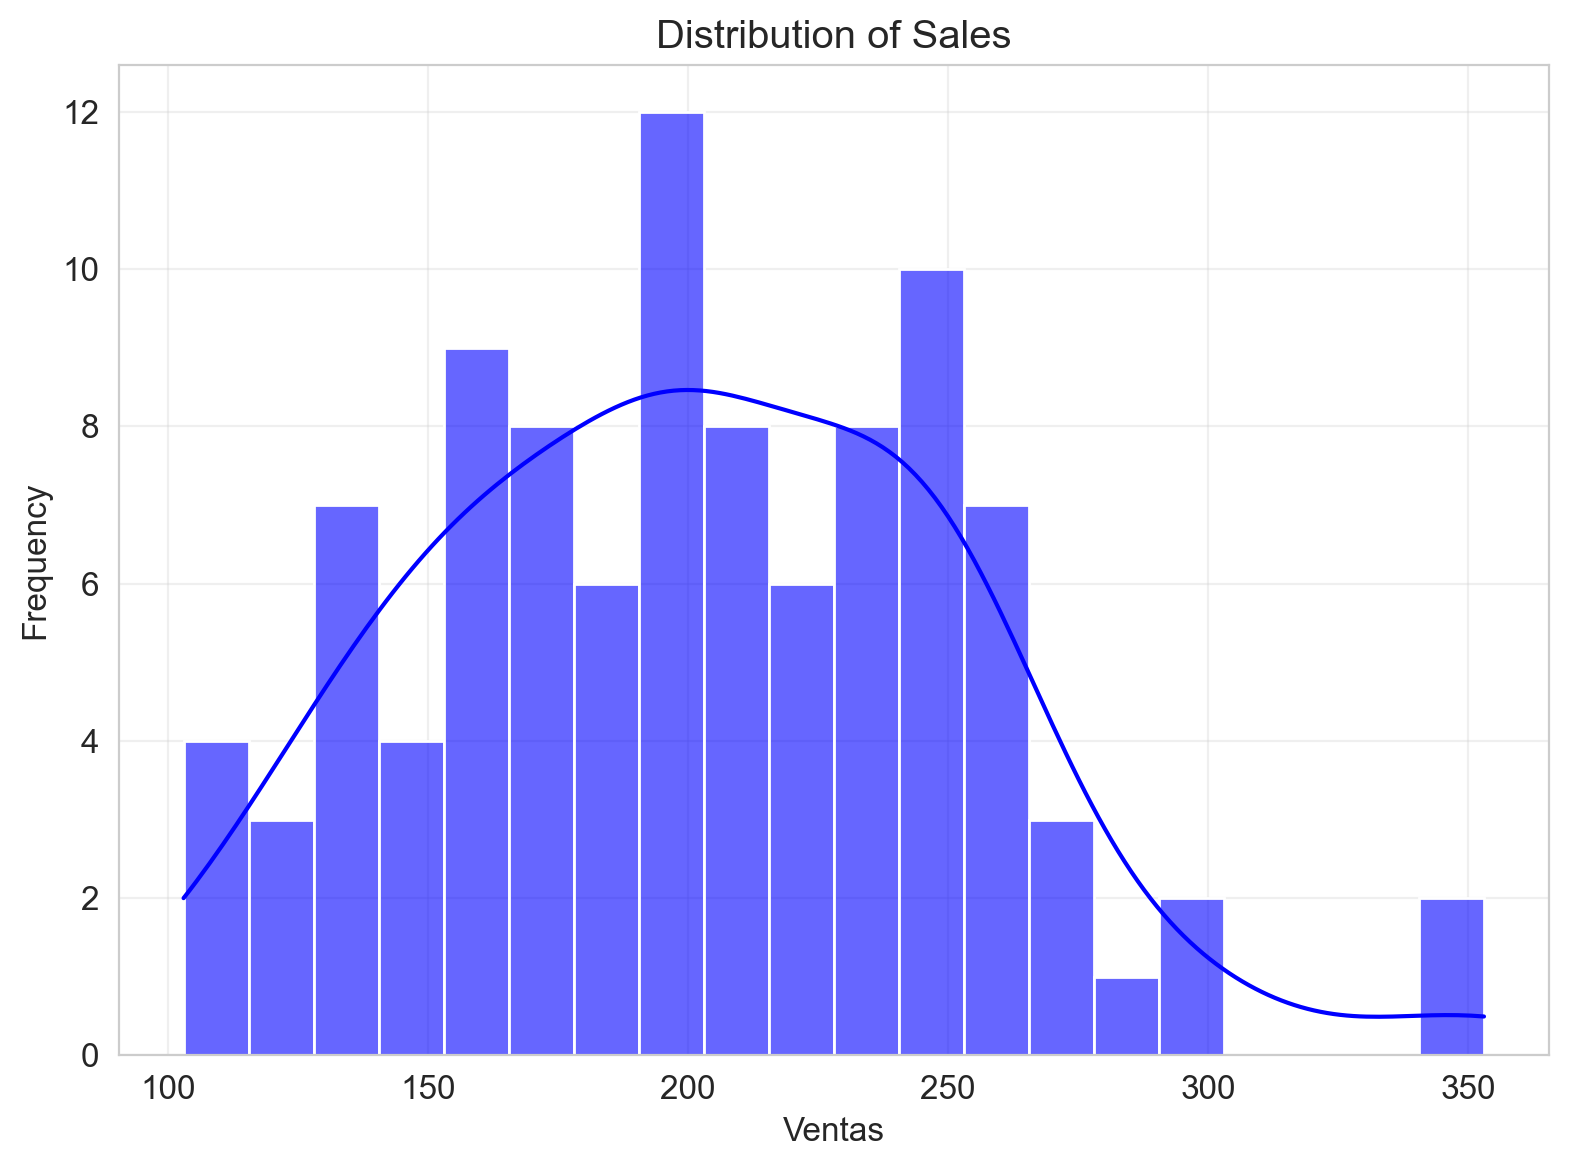

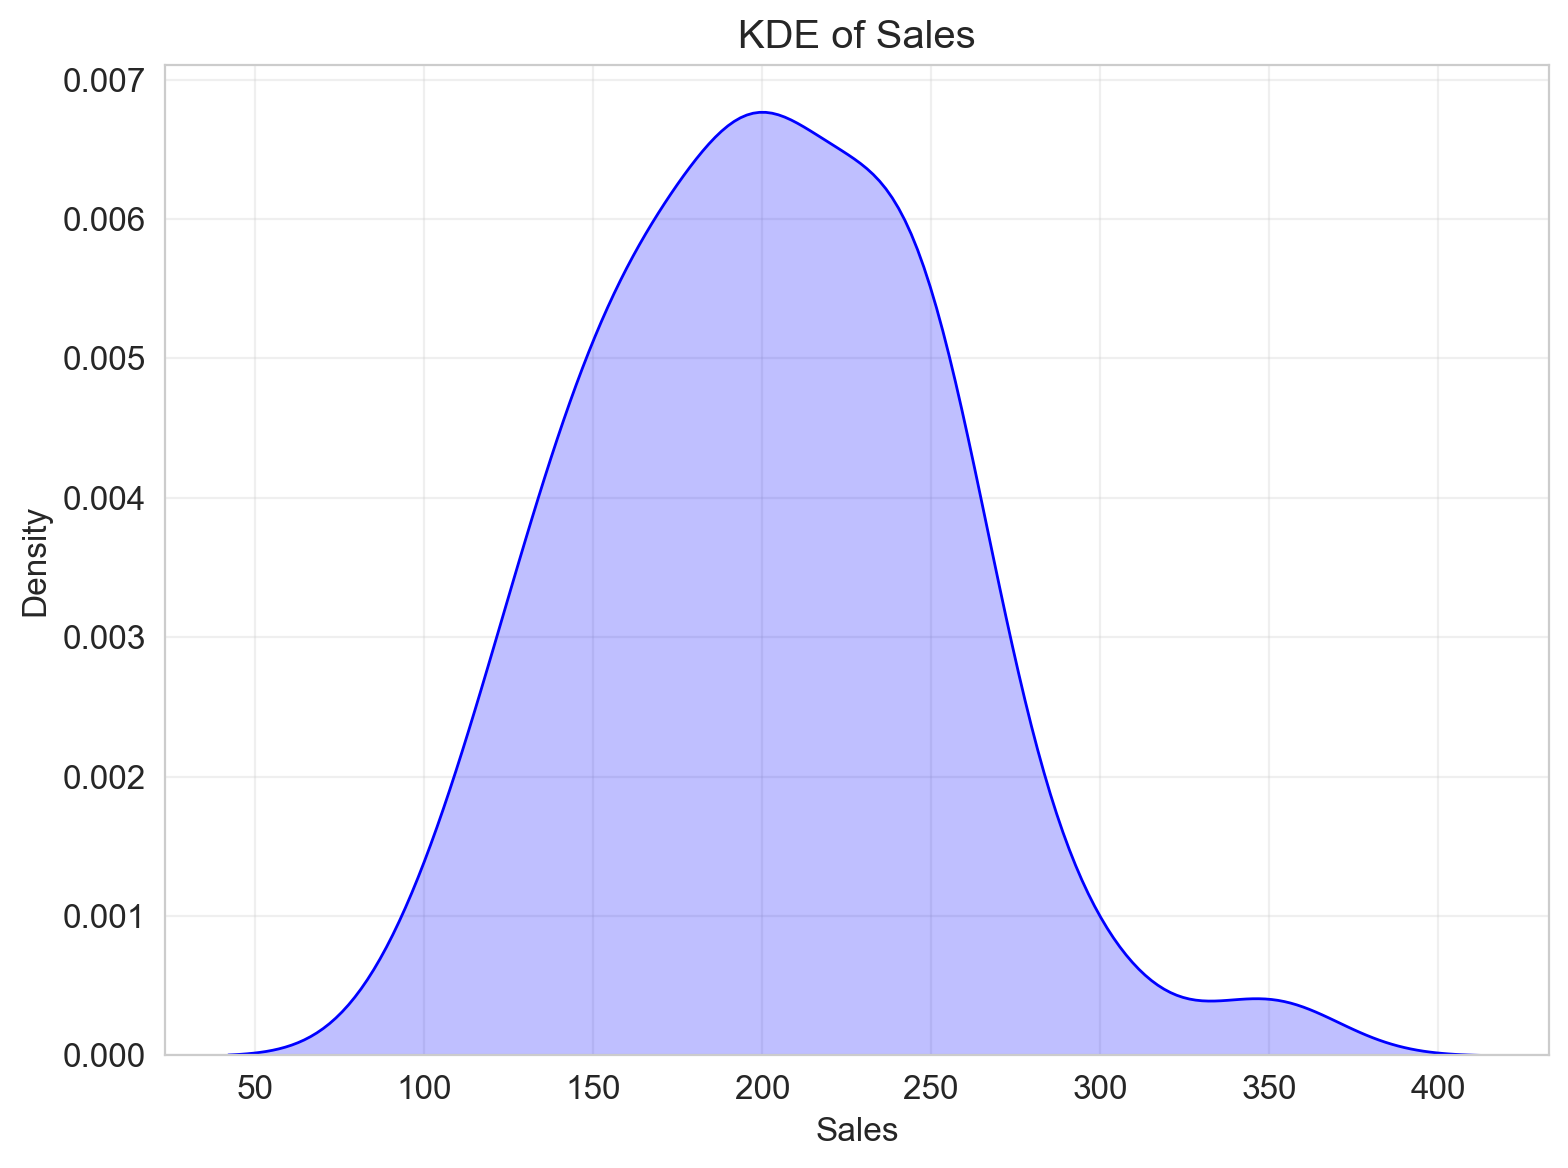

In [39]:
# Generate synthetic dataset
np.random.seed(42)
data_dist = {
    "Tienda": np.random.choice(["Norte", "Sur", "Este", "Oeste"], size=100),
    "Categoria": np.random.choice(["Electrónica", "Ropa", "Hogar"], size=100),
    "Ventas": np.random.normal(loc=200, scale=50, size=100).round(2),
    "Unidades_vendidas": np.random.poisson(lam=5, size=100)
}

df_dist = pd.DataFrame(data_dist)
validate_dataframe(df_dist, "Sales Data")

# Histogram + KDE for Sales
plot_histogram_kde(df_dist["Ventas"], "Ventas", bins=20, title="Distribution of Sales")

# KDE plot (density)
plt.figure(figsize=(8, 6))
sns.kdeplot(df_dist["Ventas"], fill=True, color='blue')
plt.title("KDE of Sales")
plt.xlabel("Sales")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

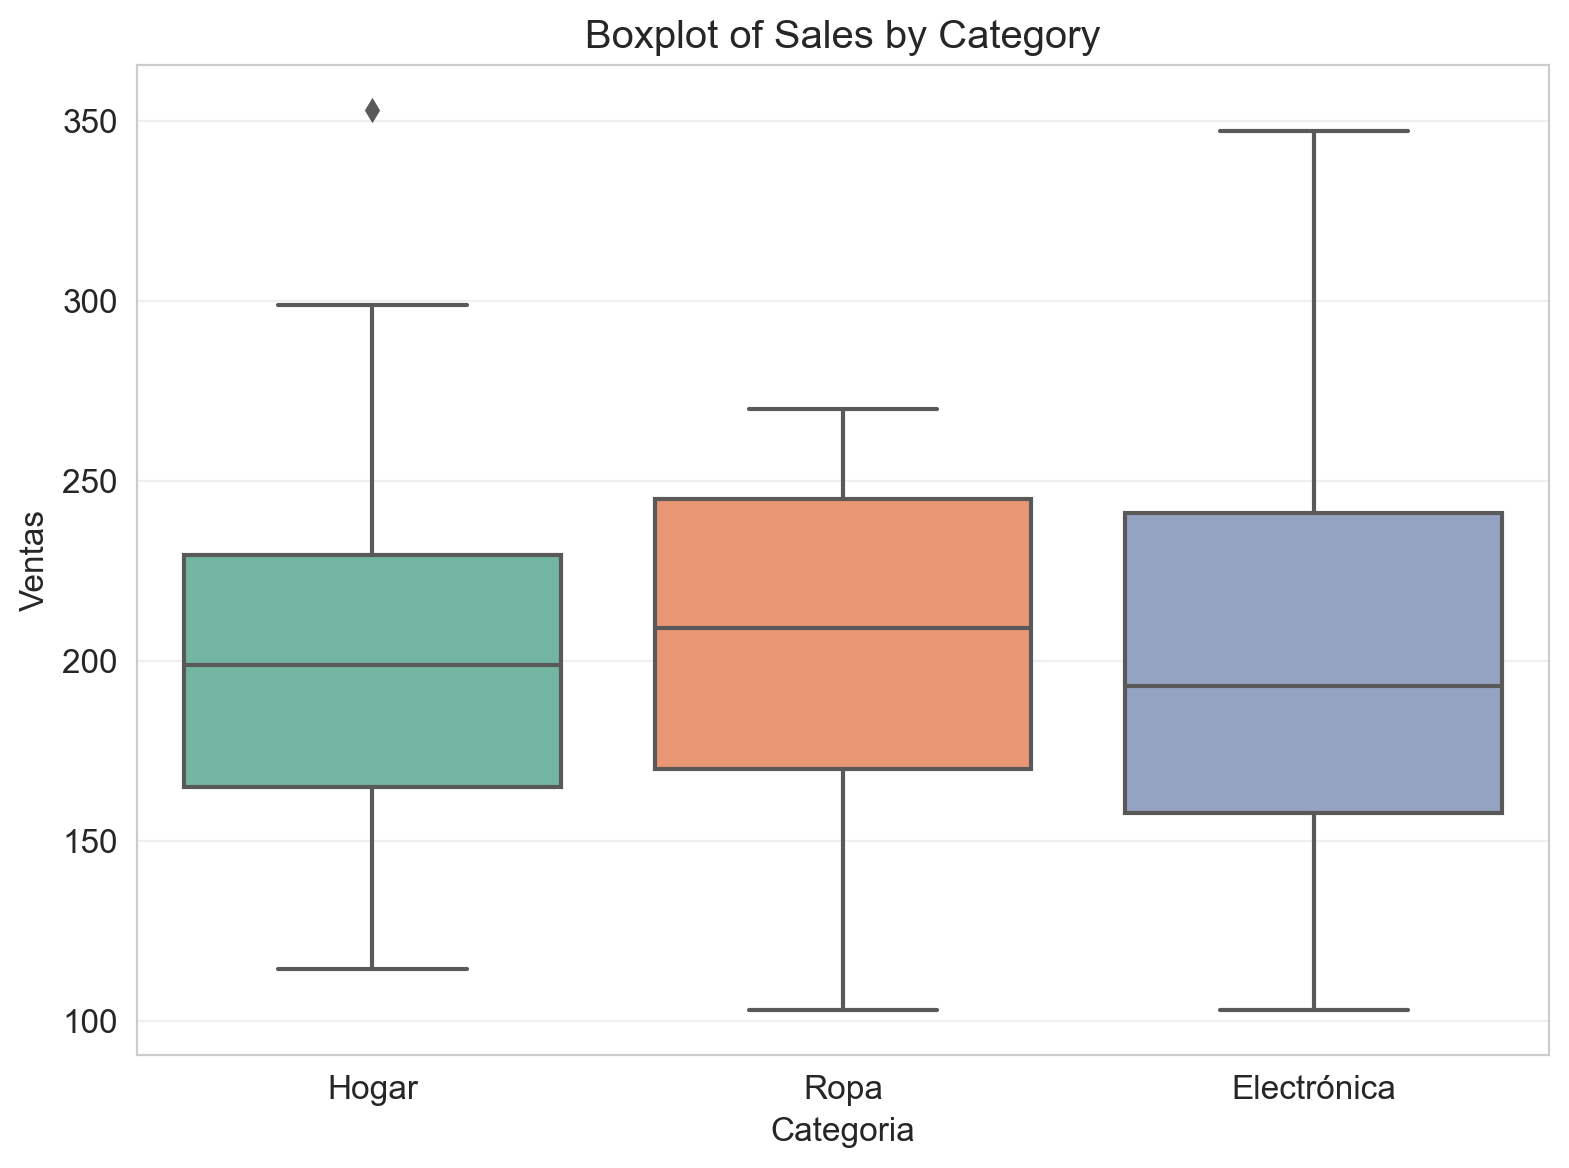

In [40]:
# Boxplot by Category
plot_boxplot(df_dist, y="Ventas", x="Categoria", title="Boxplot of Sales by Category")

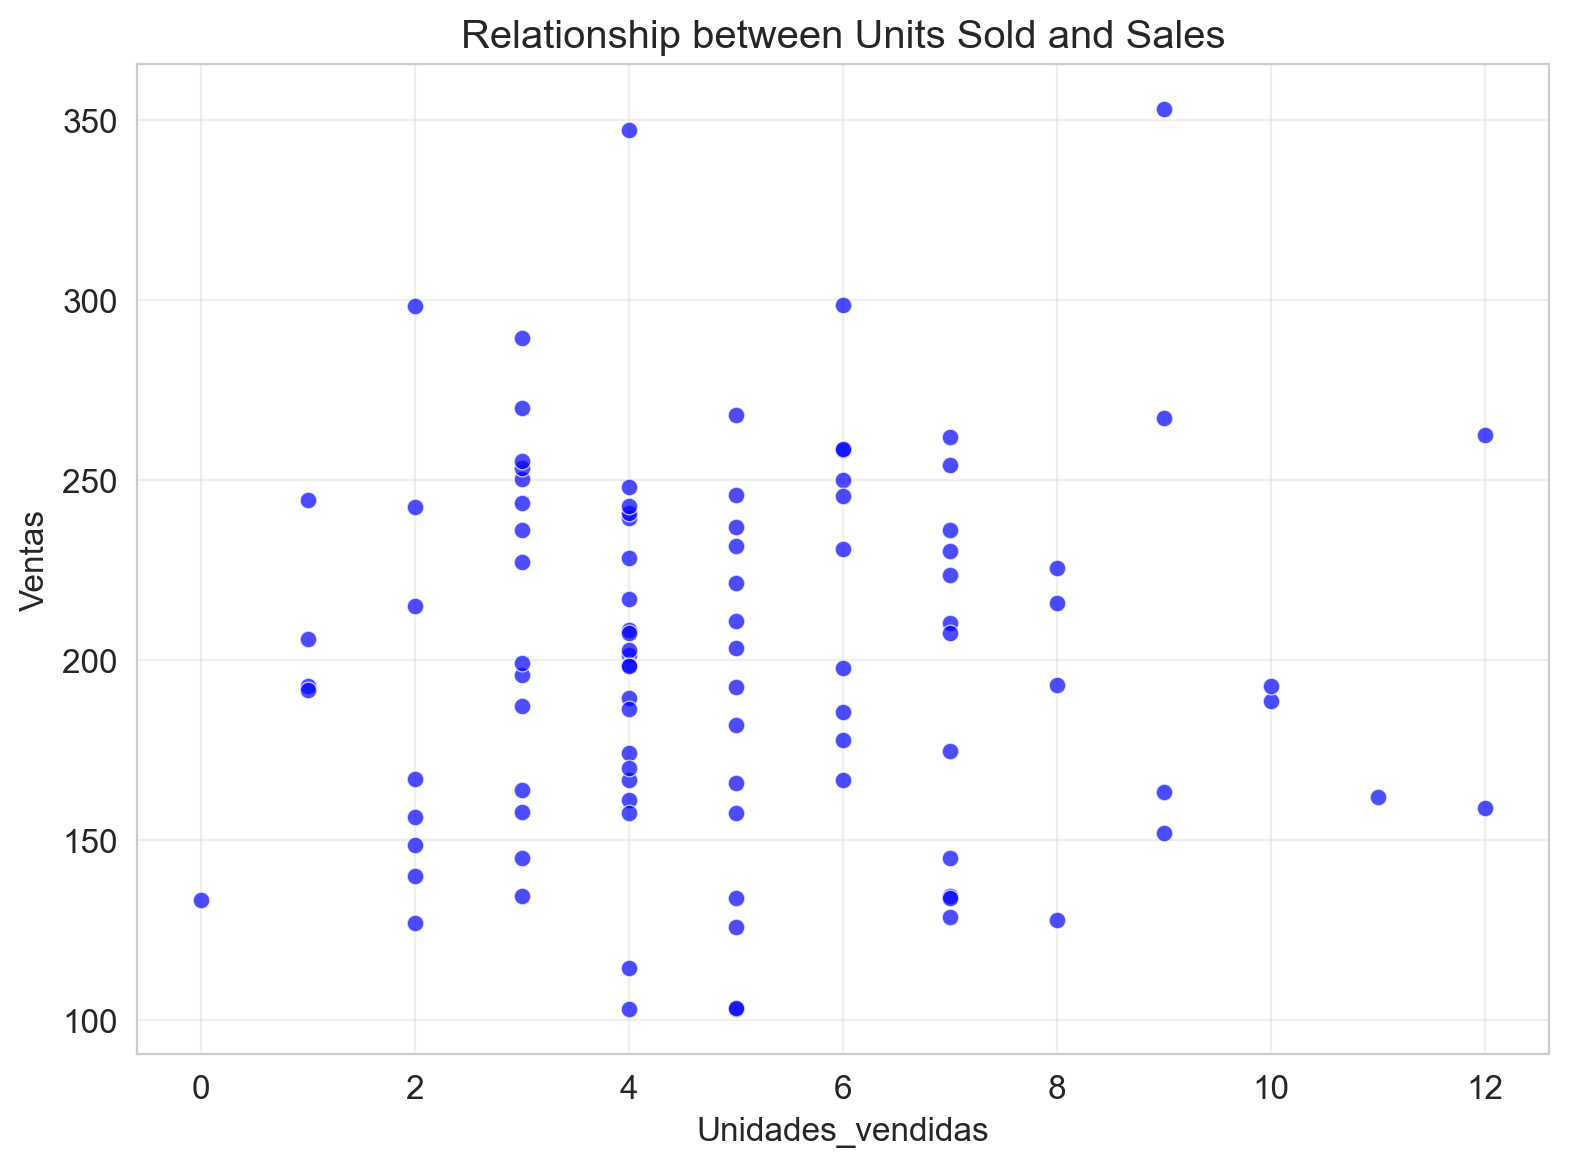

In [41]:
# Scatterplot: Units vs Sales
plot_scatter(df_dist, x="Unidades_vendidas", y="Ventas", title="Relationship between Units Sold and Sales")

## 4. Missing Data Imputation

Missing values are common in real datasets. We demonstrate:

- **Mean / Median / Mode imputation** using `SimpleImputer`
- **KNN imputation** using `KNNImputer` (leverages similarity between rows)

We validate the effectiveness by checking the percentage of missing values before and after imputation.

In [42]:
# Create dataset with missing values
data_missing = {
    "Edad": [25, np.nan, 35, 40, 29, 31, np.nan, 28, 50, 45],
    "Ingresos": [50000, 60000, np.nan, 80000, 55000, np.nan, 62000, 70000, 72000, np.nan],
    "Genero": ["Masculino", "Femenino", np.nan, "Masculino", "Femenino",
               "Masculino", "Femenino", np.nan, "Femenino", "Masculino"],
    "Ciudad": ["CDMX", "Guadalajara", "Monterrey", np.nan, "CDMX",
               "Guadalajara", "Monterrey", "CDMX", np.nan, "Monterrey"],
    "Compras": [5, 7, 6, 8, np.nan, 4, 3, 7, 5, np.nan]
}

df_missing = pd.DataFrame(data_missing)
validate_dataframe(df_missing, "Data with Missing Values")

# Show missing percentage
missing_pct = df_missing.isnull().mean() * 100
print("Missing percentage before imputation:")
print(missing_pct)

# Imputation strategies
# Edad -> mean
imputer_mean = SimpleImputer(strategy="mean")
df_missing["Edad"] = imputer_mean.fit_transform(df_missing[["Edad"]])

# Compras -> median
imputer_median = SimpleImputer(strategy="median")
df_missing["Compras"] = imputer_median.fit_transform(df_missing[["Compras"]])

# Genero -> most frequent (mode)
imputer_mode = SimpleImputer(strategy="most_frequent")
df_missing["Genero"] = imputer_mode.fit_transform(df_missing[["Genero"]]).ravel()

# Ciudad -> constant (fill with "CDMX")
imputer_constant = SimpleImputer(strategy="constant", fill_value="CDMX")
df_missing["Ciudad"] = imputer_constant.fit_transform(df_missing[["Ciudad"]]).ravel()

# Ingresos -> KNN imputation (using Edad, Compras as features)
imputer_knn = KNNImputer(n_neighbors=3)
df_missing["Ingresos"] = imputer_knn.fit_transform(df_missing[["Ingresos", "Compras", "Edad"]])

# Check missing after imputation
missing_pct_after = df_missing.isnull().mean() * 100
print("\nMissing percentage after imputation:")
print(missing_pct_after)

# Display cleaned data
print("\nCleaned DataFrame:")
display(df_missing.head(10))

--- Data with Missing Values Validation ---
Shape: (10, 5)
Column names: ['Edad', 'Ingresos', 'Genero', 'Ciudad', 'Compras']
Data types:
Edad        float64
Ingresos    float64
Genero       object
Ciudad       object
Compras     float64
dtype: object
Missing values per column:
Edad        2
Ingresos    3
Genero      2
Ciudad      2
Compras     2
dtype: int64
First 5 rows:
   Edad  Ingresos     Genero       Ciudad  Compras
0  25.0   50000.0  Masculino         CDMX      5.0
1   NaN   60000.0   Femenino  Guadalajara      7.0
2  35.0       NaN        NaN    Monterrey      6.0
3  40.0   80000.0  Masculino          NaN      8.0
4  29.0   55000.0   Femenino         CDMX      NaN


Missing percentage before imputation:
Edad        20.0
Ingresos    30.0
Genero      20.0
Ciudad      20.0
Compras     20.0
dtype: float64

Missing percentage after imputation:
Edad        0.0
Ingresos    0.0
Genero      0.0
Ciudad      0.0
Compras     0.0
dtype: float64

Cleaned DataFrame:


,Edad,Ingresos,Genero,Ciudad,Compras
0,25.000,50000.000000,Masculino,CDMX,5.0
1,35.375,60000.000000,Femenino,Guadalajara,7.0
2,35.000,67333.333333,Femenino,Monterrey,6.0
3,40.000,80000.000000,Masculino,CDMX,8.0
4,29.000,55000.000000,Femenino,CDMX,5.5
5,31.000,62333.333333,Masculino,Guadalajara,4.0
6,35.375,62000.000000,Femenino,Monterrey,3.0
7,28.000,70000.000000,Femenino,CDMX,7.0
8,50.000,72000.000000,Femenino,CDMX,5.0
9,45.000,70666.666667,Masculino,Monterrey,5.5


## 5. Outlier Detection

Outliers can skew analysis and model performance. We apply two methods:

- **Interquartile Range (IQR)** – statistical rule (values beyond 1.5×IQR from quartiles)
- **Isolation Forest** – unsupervised anomaly detection that isolates outliers by random partitioning.

We visualise outliers using boxplots and flag them for potential treatment.

--- Data with Outliers Validation ---
Shape: (100, 2)
Column names: ['Edad', 'Ingresos']
Data types:
Edad        float64
Ingresos    float64
dtype: object
Missing values per column:
Edad        0
Ingresos    0
dtype: int64
First 5 rows:
        Edad      Ingresos
0  32.483571  38677.034064
1  29.308678  46634.837418
2  33.238443  47258.283868
3  37.615149  43581.781846
4  28.829233  48709.714307


Outliers in Edad (IQR): [74, 95, 96, 97, 98, 99]
Outliers in Ingresos (IQR): [95, 96, 97, 98, 99]


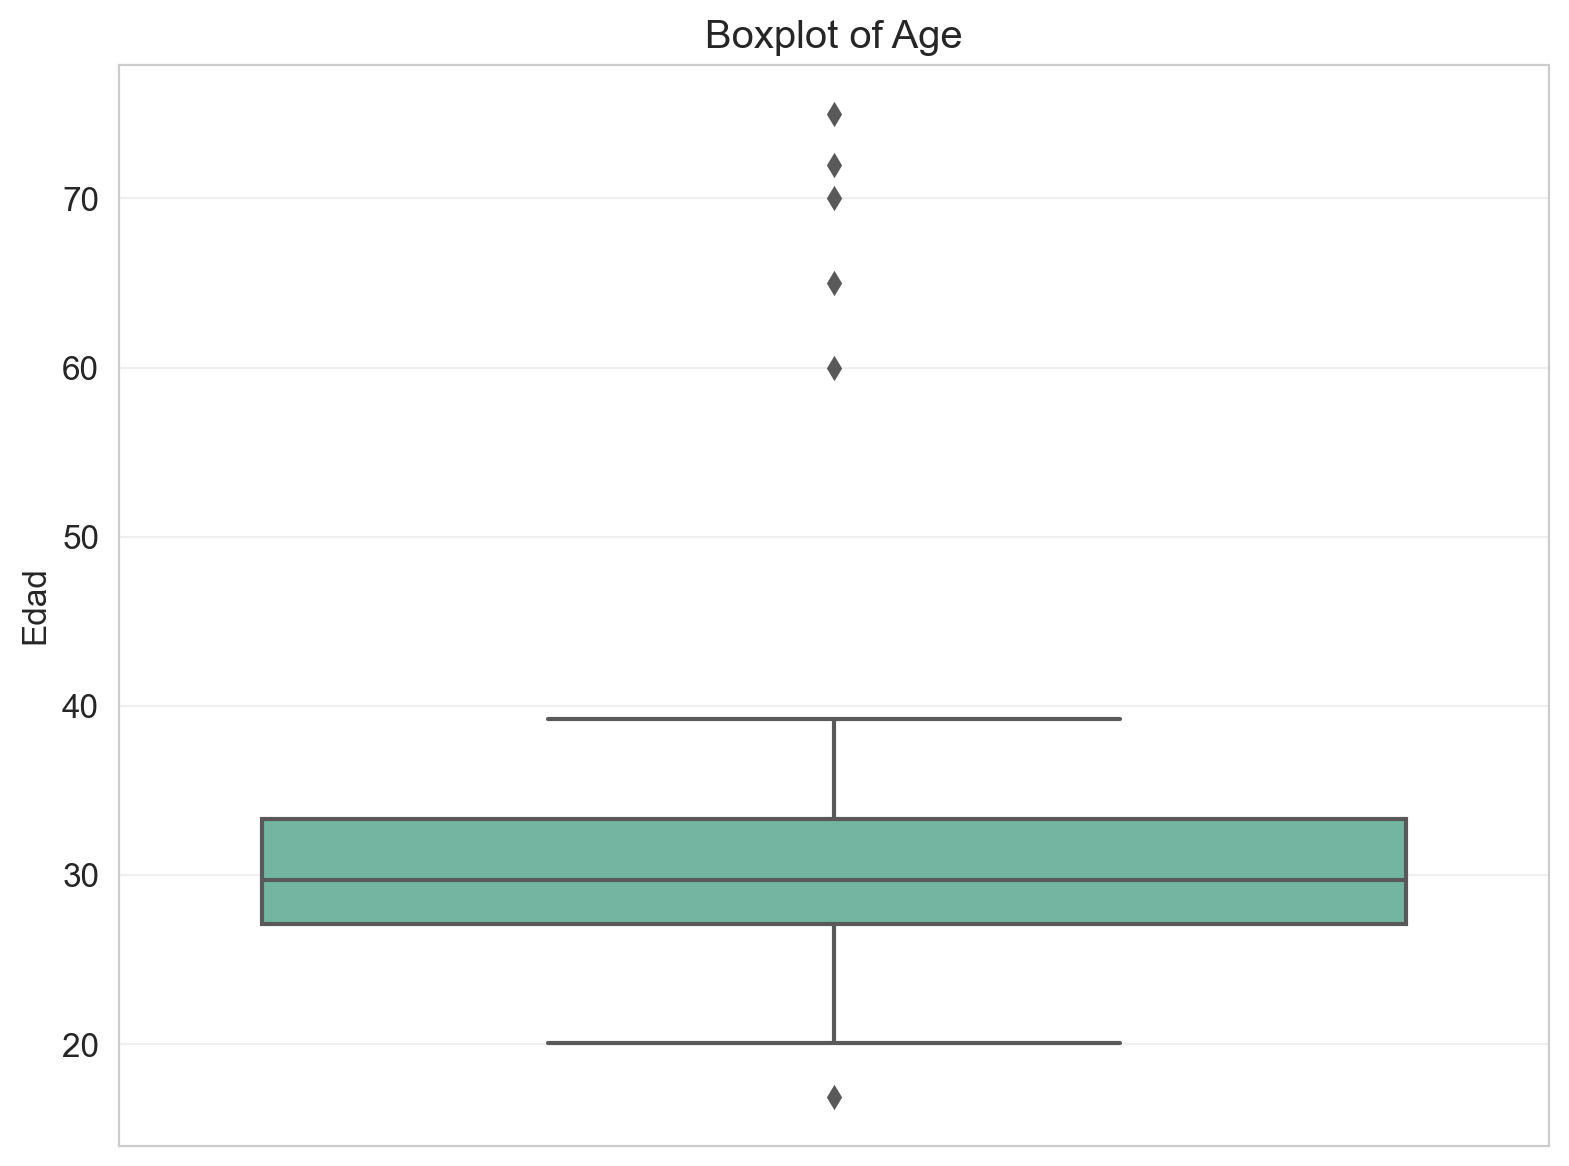

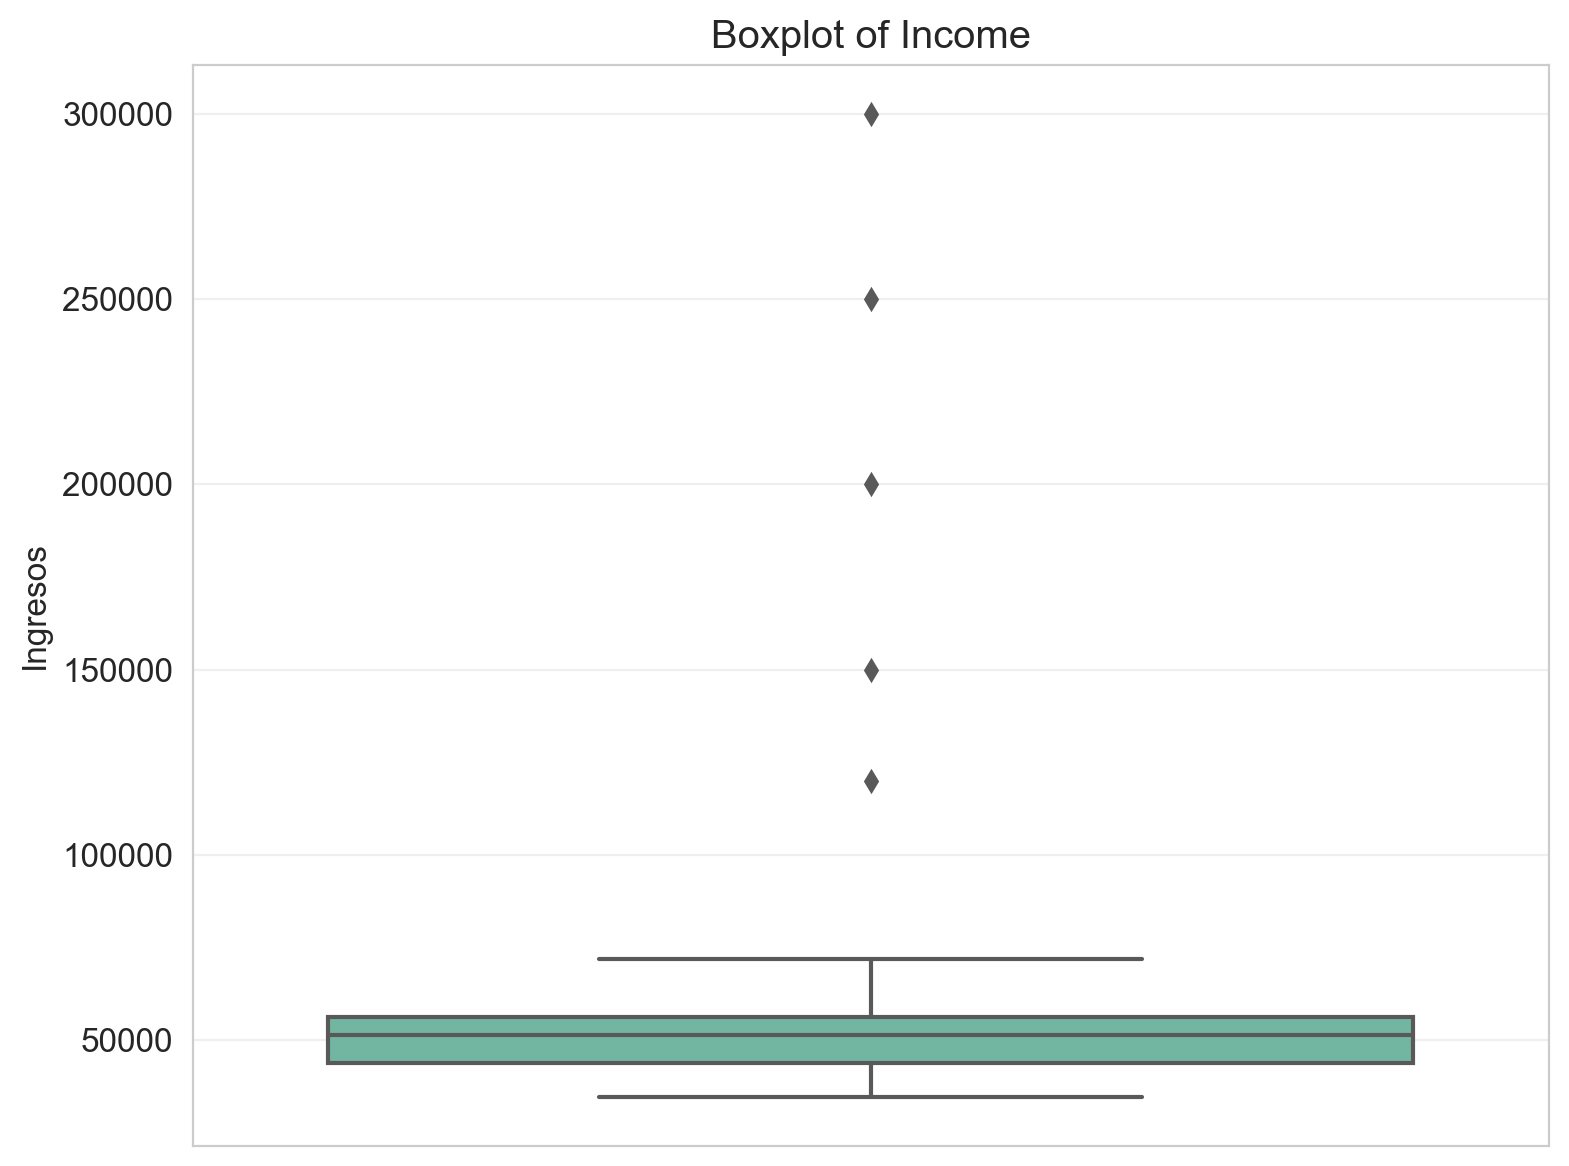

Outliers (Isolation Forest): [95, 96, 97, 98, 99]


C:\Users\phabe\miniconda3\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


In [43]:
# Generate data with outliers
np.random.seed(42)
edad = np.random.normal(30, 5, 100)
ingresos = np.random.normal(50000, 8000, 100)

# Introduce extreme outliers
edad[95:] = [60, 65, 70, 72, 75]
ingresos[95:] = [120000, 150000, 200000, 250000, 300000]

df_outliers = pd.DataFrame({"Edad": edad, "Ingresos": ingresos})
validate_dataframe(df_outliers, "Data with Outliers")

# IQR detection function
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)

# Detect outliers for Edad and Ingresos
outliers_edad_iqr = df_outliers.index[detect_outliers_iqr(df_outliers["Edad"])].tolist()
outliers_ingresos_iqr = df_outliers.index[detect_outliers_iqr(df_outliers["Ingresos"])].tolist()

print(f"Outliers in Edad (IQR): {outliers_edad_iqr}")
print(f"Outliers in Ingresos (IQR): {outliers_ingresos_iqr}")

# Visualise with boxplots
plot_boxplot(df_outliers, y="Edad", title="Boxplot of Age")
plot_boxplot(df_outliers, y="Ingresos", title="Boxplot of Income")

# Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_outliers["Outlier_IF"] = iso_forest.fit_predict(df_outliers[["Edad", "Ingresos"]])
outliers_if = df_outliers.index[df_outliers["Outlier_IF"] == -1].tolist()
print(f"Outliers (Isolation Forest): {outliers_if}")

## 6. Data Anonymization

To protect privacy, we apply:

- **Pseudonymization** – replace names with unique IDs
- **Masking** – hide parts of sensitive data (e.g., last four digits of phone)
- **Generalisation** – reduce precision (e.g., salary range instead of exact value)
- **Removal** – drop unnecessary identifiers (e.g., email)

In [44]:
# Sample personal data
data_personal = {
    "Nombre": ["Juan Pérez", "Ana García", "Luis Torres", "Marta López", "Carlos Ruiz"],
    "Edad": [23, 45, 34, 29, 52],
    "Email": ["juanp@gmail.com", "ana_g@hotmail.com", "luis.torres@yahoo.com",
              "martalopez@gmail.com", "carlosr@outlook.com"],
    "Teléfono": ["555-1234", "555-5678", "555-8765", "555-4321", "555-3456"],
    "Ciudad": ["CDMX", "Monterrey", "Guadalajara", "CDMX", "Puebla"],
    "Salario": [35000, 55000, 42000, 39000, 60000]
}

df_personal = pd.DataFrame(data_personal)
validate_dataframe(df_personal, "Original Personal Data")

# Pseudonymization: replace names with IDs
df_personal["Nombre"] = ["ID_{:03d}".format(i) for i in range(1, len(df_personal)+1)]

# Masking: hide last four digits of phone
df_personal["Teléfono"] = df_personal["Teléfono"].apply(lambda x: x[:-4] + "****")

# Remove email column
df_personal = df_personal.drop(columns=["Email"])

# Generalisation: salary ranges
def salary_range(sal):
    if sal <= 30000:
        return "bajo"
    elif sal <= 50000:
        return "medio"
    else:
        return "alto"

df_personal["Salario"] = df_personal["Salario"].apply(salary_range)

print("Anonymized DataFrame:")
display(df_personal.head(10))

--- Original Personal Data Validation ---
Shape: (5, 6)
Column names: ['Nombre', 'Edad', 'Email', 'Teléfono', 'Ciudad', 'Salario']
Data types:
Nombre      object
Edad         int64
Email       object
Teléfono    object
Ciudad      object
Salario      int64
dtype: object
Missing values per column:
Nombre      0
Edad        0
Email       0
Teléfono    0
Ciudad      0
Salario     0
dtype: int64
First 5 rows:
        Nombre  Edad                  Email  Teléfono       Ciudad  Salario
0   Juan Pérez    23        juanp@gmail.com  555-1234         CDMX    35000
1   Ana García    45      ana_g@hotmail.com  555-5678    Monterrey    55000
2  Luis Torres    34  luis.torres@yahoo.com  555-8765  Guadalajara    42000
3  Marta López    29   martalopez@gmail.com  555-4321         CDMX    39000
4  Carlos Ruiz    52    carlosr@outlook.com  555-3456       Puebla    60000


Anonymized DataFrame:


,Nombre,Edad,Teléfono,Ciudad,Salario
0,ID_001,23,555-****,CDMX,medio
1,ID_002,45,555-****,Monterrey,alto
2,ID_003,34,555-****,Guadalajara,medio
3,ID_004,29,555-****,CDMX,medio
4,ID_005,52,555-****,Puebla,alto


## 7. Feature Scaling

Many machine learning algorithms require features to be on a similar scale. We demonstrate **Min‑Max scaling** (normalisation) which maps values to a [0,1] range. Other scalers (StandardScaler, RobustScaler) are also available but not shown here for brevity.

In [36]:
# Create sample data with different ranges
data_scale = {
    "Edad": [18, 22, 35, 45, 60, 75],
    "Ingresos": [15000, 18000, 35000, 60000, 85000, 120000],
    "Gastos": [200, 250, 300, 500, 700, 1000]
}

df_scale = pd.DataFrame(data_scale)
validate_dataframe(df_scale, "Original Data with Different Ranges")

# Min-Max scaling
minmax = MinMaxScaler()
df_scaled = pd.DataFrame(minmax.fit_transform(df_scale), columns=df_scale.columns)
validate_dataframe(df_scaled, "Min-Max Scaled Data")

print("Original data:")
display(df_scale)
print("\nScaled data:")
display(df_scaled)

--- Original Data with Different Ranges Validation ---
Shape: (6, 3)
Column names: ['Edad', 'Ingresos', 'Gastos']
Data types:
Edad        int64
Ingresos    int64
Gastos      int64
dtype: object
Missing values per column:
Edad        0
Ingresos    0
Gastos      0
dtype: int64
First 5 rows:
   Edad  Ingresos  Gastos
0    18     15000     200
1    22     18000     250
2    35     35000     300
3    45     60000     500
4    60     85000     700


--- Min-Max Scaled Data Validation ---
Shape: (6, 3)
Column names: ['Edad', 'Ingresos', 'Gastos']
Data types:
Edad        float64
Ingresos    float64
Gastos      float64
dtype: object
Missing values per column:
Edad        0
Ingresos    0
Gastos      0
dtype: int64
First 5 rows:
       Edad  Ingresos  Gastos
0  0.000000  0.000000  0.0000
1  0.070175  0.028571  0.0625
2  0.298246  0.190476  0.1250
3  0.473684  0.428571  0.3750
4  0.736842  0.666667  0.6250


Original data:


,Edad,Ingresos,Gastos
0,18,15000,200
1,22,18000,250
2,35,35000,300
3,45,60000,500
4,60,85000,700
5,75,120000,1000



Scaled data:


,Edad,Ingresos,Gastos
0,0.000000,0.000000,0.0000
1,0.070175,0.028571,0.0625
2,0.298246,0.190476,0.1250
3,0.473684,0.428571,0.3750
4,0.736842,0.666667,0.6250
5,1.000000,1.000000,1.0000


## Summary and Next Steps

**Accomplished in this notebook:**

- Demonstrated categorical encoding (ordinal, binary, one‑hot) using scikit‑learn.
- Engineered cyclic features from date/time variables to preserve periodicity.
- Visualised distributions and relationships using histograms, KDE, boxplots, and scatterplots.
- Handled missing values with mean, median, mode, constant, and KNN imputation.
- Detected outliers via IQR and Isolation Forest.
- Applied anonymization techniques: pseudonymization, masking, generalisation, and removal.
- Performed Min‑Max scaling for feature normalisation.

**Key insights:**

- Ordinal encoding preserves order; one‑hot encoding avoids imposing false order.
- Cyclic encoding is essential for time features to capture seasonal patterns.
- IQR is simple but static; Isolation Forest is more robust for multivariate outliers.
- Anonymization is critical for data privacy in real‑world applications.
- Scaling is necessary for gradient‑based models and distance‑based algorithms.

**Suggested next steps (critical thinking):**

1. **Pipeline integration** – wrap preprocessing steps into a scikit‑learn `Pipeline` with `ColumnTransformer` for clean, reproducible workflows.
2. **Advanced imputation** – explore predictive imputation (e.g., using regression or MICE) for more accurate missing value handling.
3. **Outlier treatment** – compare winsorisation, transformation, or removal strategies and evaluate their impact on model performance.
4. **Feature selection** – after encoding and scaling, apply feature selection methods (e.g., mutual information, recursive elimination) to reduce dimensionality.
5. **Automated reporting** – use libraries like `pandas-profiling` or `ydata-profiling` for rapid exploratory data analysis.

This notebook serves as a solid foundation for data preprocessing in any data science project.